# Fashion-MNIST Representation Learning and Classification

This project compares different dimensionality reduction and representation learning methods on the Fashion-MNIST dataset.

Three approaches are evaluated:
- **Self-Organizing Map (SOM)** for topology-based dimensionality reduction
- **Restricted Boltzmann Machine (RBM)** for learned hidden representations
- **Variational Autoencoder (VAE)** for neural latent representation learning

The original and reduced representations are evaluated using **Random Forest** and **AdaBoost** classifiers, with comparisons based on classification accuracy and execution time.

A repeated experiment is also conducted for the VAE representation to evaluate the stability of downstream classification performance.

## 1. Fashion-MNIST Dataset and Preprocessing

Fashion-MNIST contains **70,000 grayscale images** of clothing items across 10 classes, including 60,000 training samples and 10,000 test samples. Each image has a resolution of **28 × 28 pixels**.

Several training samples are first visualized to inspect the image classes. The images are then flattened into **784-dimensional feature vectors** and normalized to `[0, 1]` for representation learning.

In [1]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import fashion_mnist

from sklearn.neural_network import BernoulliRBM
from minisom import MiniSom

# Reproducibility
random.seed(5718)
np.random.seed(5718)
tf.random.set_seed(5718)

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)
print("Number of classes:", len(np.unique(y_train)))

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)
Number of classes: 10


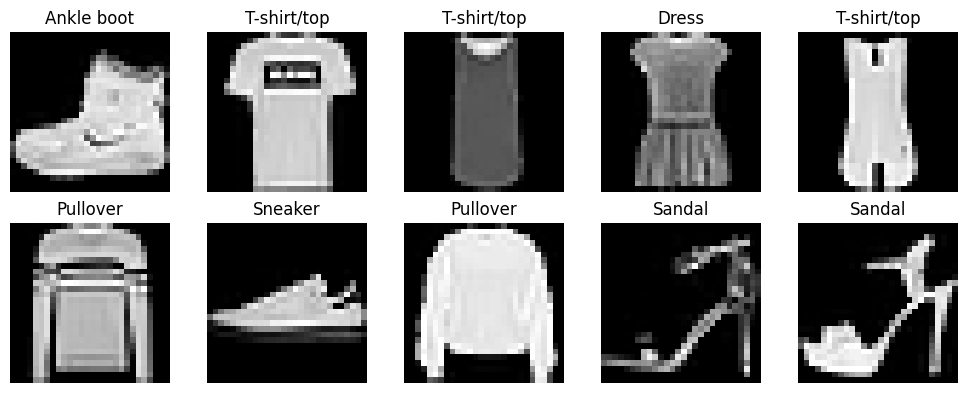

In [2]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(class_names[y_train[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
# Flatten 28x28 images into 784-dimensional vectors
X_train = x_train.reshape(x_train.shape[0], -1)
X_test = x_test.reshape(x_test.shape[0], -1)

# Normalize pixel values to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 784)
Test data shape: (10000, 784)


## 2. Self-Organizing Map (SOM)

A **Self-Organizing Map (SOM)** projects high-dimensional samples onto a low-dimensional grid while attempting to preserve their neighborhood relationships.

Here, each 784-dimensional Fashion-MNIST image is mapped to its **best-matching unit (BMU)** on a two-dimensional SOM grid. The `(x, y)` coordinates of the winning neuron are then used as a compact 2-dimensional representation for downstream classification.

In [4]:
# Start timing the complete SOM representation process
start_time = time.time()

# Determine the SOM grid size based on the number of training samples
# The resulting square grid provides a 2D space for organizing the input images
som_grid_size = round(np.sqrt(5 * np.sqrt(X_train.shape[0])))

# Create the SOM
# Each neuron receives a 784-dimensional image vector as input
som = MiniSom(
    x=som_grid_size,
    y=som_grid_size,
    input_len=784,
    sigma=1.0,
    learning_rate=0.5,
    random_seed=5718
)

# Initialize SOM weights using the training data
som.random_weights_init(X_train)

# Train the SOM by repeatedly sampling observations from the training set
# Training is performed only on X_train to avoid using test-set information
som.train_random(X_train, num_iteration=1000)

# Transform each image into the coordinates of its best-matching unit (BMU)
# The original 784-dimensional vector is therefore represented by
# two features: the x- and y-coordinates of the winning neuron
def som_transform(X):
    reduced = []

    for sample in X:
        winner = som.winner(sample)
        reduced.append(winner)

    return np.array(reduced)

# Generate 2D SOM representations for the training and test sets
X_train_som = som_transform(X_train)
X_test_som = som_transform(X_test)

# Record total training and transformation time
som_transform_time = time.time() - start_time

print(f"SOM grid size: {som_grid_size} x {som_grid_size}")
print(f"SOM transform time: {som_transform_time:.2f} seconds")
print("SOM reduced train shape:", X_train_som.shape)
print("SOM reduced test shape:", X_test_som.shape)

SOM grid size: 35 x 35
SOM transform time: 367.32 seconds
SOM reduced train shape: (60000, 2)
SOM reduced test shape: (10000, 2)


## 3. Restricted Boltzmann Machine (RBM)

A **Restricted Boltzmann Machine (RBM)** is an unsupervised neural model that learns latent features through interactions between visible and hidden units.

Here, a Bernoulli RBM compresses each **784-dimensional image vector into 64 learned hidden features**. The RBM is fitted only on the training set, and the learned transformation is then applied to both the training and test data.

In [5]:
# Start timing the complete RBM training and transformation process
start_time = time.time()

# Create a Bernoulli RBM with 64 hidden units
# Each 784-dimensional image will be represented by 64 learned hidden features
rbm = BernoulliRBM(
    n_components=64,
    learning_rate=0.05,
    n_iter=10,
    random_state=5718,
    verbose=True
)

# Fit the RBM only on the training data
# The model learns latent patterns from the normalized image pixels
rbm.fit(X_train)

# Transform the original 784-dimensional images into
# 64-dimensional hidden representations
X_train_rbm = rbm.transform(X_train)
X_test_rbm = rbm.transform(X_test)

# Record total training and transformation time
rbm_transform_time = time.time() - start_time

print(f"RBM transform time: {rbm_transform_time:.2f} seconds")
print("RBM reduced train shape:", X_train_rbm.shape)
print("RBM reduced test shape:", X_test_rbm.shape)

[BernoulliRBM] Iteration 1, pseudo-likelihood = -235.72, time = 7.29s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -222.16, time = 7.73s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -216.84, time = 7.61s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -215.21, time = 7.51s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -210.54, time = 7.54s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -215.11, time = 7.52s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -215.00, time = 7.57s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -212.66, time = 7.56s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -208.57, time = 7.53s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -205.91, time = 7.52s
RBM transform time: 76.17 seconds
RBM reduced train shape: (60000, 64)
RBM reduced test shape: (10000, 64)


## 4. Variational Autoencoder (VAE)

A **Variational Autoencoder (VAE)** learns a probabilistic latent representation of the input data. Unlike a standard autoencoder, the encoder does not directly output a single latent vector. Instead, it estimates the mean and log-variance of a latent distribution, from which a latent vector is sampled using the reparameterization trick.

In this experiment, each 784-dimensional Fashion-MNIST image is compressed into a **64-dimensional latent representation**. The VAE is trained by jointly minimizing reconstruction loss and KL-divergence loss.

### Encoder and Decoder

In [6]:
latent_dim = 64

# -------------------------
# Encoder
# -------------------------

# Input: flattened 28x28 image with 784 pixel features
encoder_input = layers.Input(shape=(784,))

# Gradually compress the input representation
x = layers.Dense(256, activation="relu")(encoder_input)
x = layers.Dense(128, activation="relu")(x)

# The encoder predicts the parameters of the latent distribution:
# mean (μ) and log-variance (log σ²)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)


# Reparameterization trick:
# z = μ + σ * ε, where ε is sampled from a standard normal distribution
def sampling(args):
    z_mean, z_log_var = args

    epsilon = tf.random.normal(
        shape=tf.shape(z_mean),
        seed=5718
    )

    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# Sample the latent vector z
z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

# Encoder returns the distribution parameters and sampled latent vector
encoder = Model(
    encoder_input,
    [z_mean, z_log_var, z],
    name="encoder"
)


# -------------------------
# Decoder
# -------------------------

# Input: 64-dimensional latent representation
decoder_input = layers.Input(shape=(latent_dim,))

# Expand the latent vector back toward the original image dimension
x = layers.Dense(128, activation="relu")(decoder_input)
x = layers.Dense(256, activation="relu")(x)

# Reconstruct the original 784 normalized pixel values
decoder_output = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = Model(
    decoder_input,
    decoder_output,
    name="decoder"
)

### VAE Training

In [7]:
class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()

        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):

        # Extract the input data when Keras passes data as a tuple
        if isinstance(data, tuple):
            data = data[0]

        # Record operations for automatic differentiation
        with tf.GradientTape() as tape:

            # Encode the input into the latent distribution
            z_mean, z_log_var, z = self.encoder(data)

            # Reconstruct the input from the sampled latent vector
            reconstruction = self.decoder(z)

            # Reconstruction loss measures how closely the decoder
            # reproduces the original input image
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=-1
                )
            )

            # KL-divergence regularizes the latent distribution
            # toward a standard normal distribution
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1
                    + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total VAE objective
            total_loss = reconstruction_loss + kl_loss

        # Compute gradients of the total loss
        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # Update encoder and decoder parameters
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }


vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

In [8]:
# Start timing VAE training and latent feature generation
start_time = time.time()

# Train the VAE on the normalized training images
vae.fit(
    X_train,
    epochs=20,
    batch_size=256
)

# Use the latent mean as the deterministic reduced representation
X_train_vae, _, _ = encoder.predict(
    X_train,
    verbose=0
)

X_test_vae, _, _ = encoder.predict(
    X_test,
    verbose=0
)

# Record total training and transformation time
vae_transform_time = time.time() - start_time

print(f"VAE transform time: {vae_transform_time:.2f} seconds")
print("VAE reduced train shape:", X_train_vae.shape)
print("VAE reduced test shape:", X_test_vae.shape)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 5.9419 - loss: 43.0686 - reconstruction_loss: 37.1267  
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 6.6669 - loss: 39.9179 - reconstruction_loss: 33.2510
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 6.7851 - loss: 39.4542 - reconstruction_loss: 32.6692
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 6.4121 - loss: 38.1049 - reconstruction_loss: 31.6928
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 6.7860 - loss: 37.9433 - reconstruction_loss: 31.1572
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 6.5764 - loss: 37.5884 - reconstruction_loss: 31.0121
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 6.6931 - loss: 37.4402 - reconstruction_loss: 30.7471
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 6.4144 - loss: 37.2866 - reconstruction_loss: 30.8723
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss:

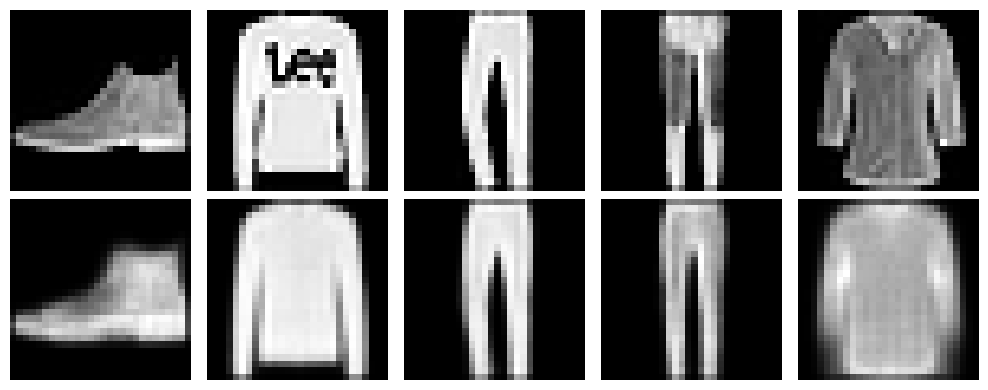

In [9]:
# Reconstruct several test images using their latent mean
z_mean_test, _, _ = encoder.predict(
    X_test[:5],
    verbose=0
)

reconstructed = decoder.predict(
    z_mean_test,
    verbose=0
)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(5):
    axes[0, i].imshow(X_test[i].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")

plt.tight_layout()
plt.show()

The reconstructed samples preserve the main visual structure and clothing category of the original images, although fine-grained details are smoothed or lost during compression. This indicates that the 64-dimensional VAE latent representation captures the dominant structural information while substantially reducing the original 784-dimensional feature space.

## 5. Classification Performance Comparison

To evaluate the quality of the learned representations, **Random Forest** and **AdaBoost** classifiers are trained on four feature sets:

- Original pixel features (**784 dimensions**)
- SOM representation (**2 dimensions**)
- RBM representation (**64 dimensions**)
- VAE latent representation (**64 dimensions**)

All classifiers use the same training and test labels. Performance is evaluated using **test accuracy**, while training and prediction time is recorded to compare computational efficiency.

In [10]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Collect the original and reduced feature representations
datasets = {
    "Original": (X_train, X_test),
    "SOM": (X_train_som, X_test_som),
    "RBM": (X_train_rbm, X_test_rbm),
    "VAE": (X_train_vae, X_test_vae)
}

results = []

# Evaluate both classifiers on each feature representation
for data_name, (X_tr, X_te) in datasets.items():

    classifiers = {
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=5718,
            n_jobs=-1
        ),
        "AdaBoost": AdaBoostClassifier(
            n_estimators=100,
            random_state=5718
        )
    }

    for clf_name, clf in classifiers.items():

        # Measure combined training and prediction time
        start_time = time.time()

        clf.fit(X_tr, y_train)
        y_pred = clf.predict(X_te)

        total_time = time.time() - start_time
        acc = accuracy_score(y_test, y_pred)

        results.append({
            "Representation": data_name,
            "Classifier": clf_name,
            "Accuracy": acc,
            "Execution Time (s)": total_time
        })

# Organize the results into a comparison table
results_df = pd.DataFrame(results)

results_df["Accuracy"] = results_df["Accuracy"].round(4)
results_df["Execution Time (s)"] = results_df["Execution Time (s)"].round(2)

results_df

,Representation,Classifier,Accuracy,Execution Time (s)
0,Original,Random Forest,0.8753,6.36
1,Original,AdaBoost,0.5288,275.60
2,SOM,Random Forest,0.7703,0.63
3,SOM,AdaBoost,0.1922,2.04
4,RBM,Random Forest,0.8306,2.56
5,RBM,AdaBoost,0.5563,56.76
6,VAE,Random Forest,0.8202,5.00
7,VAE,AdaBoost,0.5512,96.92


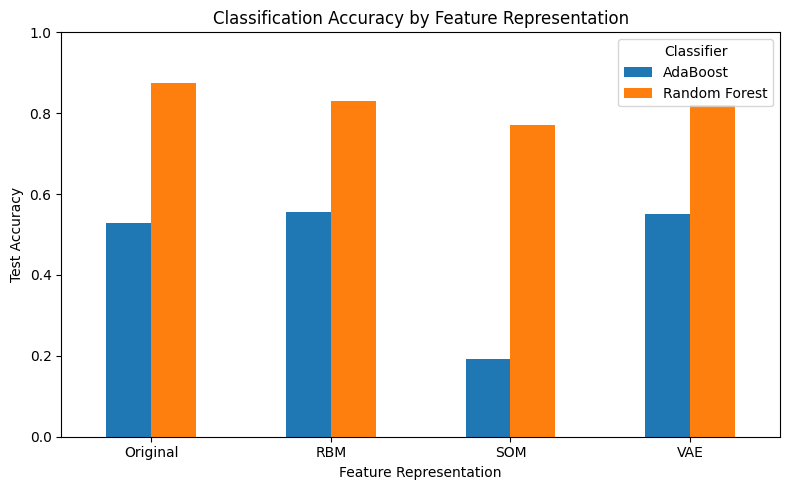

In [11]:
accuracy_pivot = results_df.pivot(
    index="Representation",
    columns="Classifier",
    values="Accuracy"
)

accuracy_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Classification Accuracy by Feature Representation")
plt.xlabel("Feature Representation")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Classifier")
plt.tight_layout()
plt.show()

### Results and Discussion

**Random Forest consistently outperformed AdaBoost** across all four feature representations. The original 784-dimensional features achieved the highest Random Forest accuracy at **87.53%**, indicating that the full pixel representation retained the most discriminative information. Dimensionality reduction reduced the feature space substantially, but this compression also introduced some loss of information relevant to classification.

Among the reduced representations, **RBM achieved the strongest Random Forest performance at 83.06%**, followed by VAE at **82.02%**. Both methods reduced the original 784 features to only 64 dimensions while retaining most of the Random Forest classification performance. RBM also slightly outperformed VAE in this run. One possible explanation is that the KL-divergence regularization used by VAE encourages a smoother and more structured latent space, which is useful for generative modeling but may remove some fine-grained information useful for classification.

The dimensionality reduction methods also affected computational efficiency. Random Forest required approximately **6.36 seconds** on the original representation, compared with **2.56 seconds** for RBM and **5.00 seconds** for VAE. AdaBoost showed an even larger reduction in execution time, decreasing from approximately **275.60 seconds** on the original features to **56.76 seconds** with RBM and **96.92 seconds** with VAE. This illustrates an important trade-off: lower-dimensional representations may sacrifice some predictive information while reducing the computational cost of downstream models.

AdaBoost behaved differently from Random Forest. While its accuracy on the original features was **52.88%**, the RBM and VAE representations achieved **55.63%** and **55.12%**, respectively. This suggests that appropriately compressed representations can sometimes make useful structure easier for weak learners to exploit. AdaBoost was nevertheless substantially slower than Random Forest, consistent with its sequential boosting procedure, where weak learners are constructed iteratively rather than independently.

**SOM produced the weakest classification results**, with Random Forest accuracy decreasing to **77.03%** and AdaBoost accuracy to only **19.22%**. Unlike RBM and VAE, which retained 64 learned features, the SOM representation compressed each 784-dimensional image into only two winning-neuron coordinates. This aggressive compression likely discarded substantial class-discriminative information.

Overall, the results show that dimensionality reduction does not necessarily improve classification accuracy. Instead, it introduces a trade-off between **representation compactness, predictive performance, and computational efficiency**. RBM provided the strongest classification performance among the reduced representations in this experiment, while VAE produced a competitive 64-dimensional latent representation with the additional ability to reconstruct the original image structure.

Because VAE training involves stochastic latent sampling, its learned representation can vary between runs. A repeated experiment is therefore conducted in the next section to evaluate the stability of VAE-based classification performance.

## 6. VAE Stability Analysis

Because VAE training contains stochastic components, different training runs can produce slightly different latent representations. To evaluate whether this variation affects downstream classification, the VAE is independently trained **five times** using the same architecture and hyperparameters.

For each run, the resulting 64-dimensional latent representation is evaluated using Random Forest and AdaBoost. The mean and standard deviation of classification accuracy are then calculated to compare performance stability.

In [12]:
# Build a fresh VAE with the same architecture used above
def build_vae(latent_dim=64):

    # Encoder
    encoder_input = layers.Input(shape=(784,))
    x = layers.Dense(256, activation="relu")(encoder_input)
    x = layers.Dense(128, activation="relu")(x)

    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)

    z = layers.Lambda(sampling)([z_mean, z_log_var])

    encoder = Model(
        encoder_input,
        [z_mean, z_log_var, z],
        name="encoder"
    )

    # Decoder
    decoder_input = layers.Input(shape=(latent_dim,))
    x = layers.Dense(128, activation="relu")(decoder_input)
    x = layers.Dense(256, activation="relu")(x)
    decoder_output = layers.Dense(
        784,
        activation="sigmoid"
    )(x)

    decoder = Model(
        decoder_input,
        decoder_output,
        name="decoder"
    )

    # Assemble and compile the VAE
    vae = VAE(encoder, decoder)
    vae.compile(optimizer="adam")

    return vae, encoder

In [13]:
stability_results = []

for run in range(1, 6):

    print(f"Running VAE experiment {run}/5...")

    # Clear previous TensorFlow model state
    tf.keras.backend.clear_session()

    start_time = time.time()

    # Build and train a fresh VAE
    vae_run, encoder_run = build_vae(latent_dim=64)

    vae_run.fit(
        X_train,
        epochs=20,
        batch_size=256,
        verbose=0
    )

    # Generate deterministic latent representations using z_mean
    X_train_vae_run, _, _ = encoder_run.predict(
        X_train,
        verbose=0
    )

    X_test_vae_run, _, _ = encoder_run.predict(
        X_test,
        verbose=0
    )

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=5718,
        n_jobs=-1
    )

    rf.fit(X_train_vae_run, y_train)
    rf_acc = accuracy_score(
        y_test,
        rf.predict(X_test_vae_run)
    )

    # AdaBoost
    ada = AdaBoostClassifier(
        n_estimators=100,
        random_state=5718
    )

    ada.fit(X_train_vae_run, y_train)
    ada_acc = accuracy_score(
        y_test,
        ada.predict(X_test_vae_run)
    )

    execution_time = time.time() - start_time

    stability_results.append({
        "Run": run,
        "Random Forest Accuracy": rf_acc,
        "AdaBoost Accuracy": ada_acc,
        "Execution Time (s)": execution_time
    })

stability_df = pd.DataFrame(stability_results)

stability_df["Random Forest Accuracy"] = (
    stability_df["Random Forest Accuracy"].round(4)
)

stability_df["AdaBoost Accuracy"] = (
    stability_df["AdaBoost Accuracy"].round(4)
)

stability_df["Execution Time (s)"] = (
    stability_df["Execution Time (s)"].round(2)
)

stability_df

Running VAE experiment 1/5...
Running VAE experiment 2/5...
Running VAE experiment 3/5...
Running VAE experiment 4/5...
Running VAE experiment 5/5...


,Run,Random Forest Accuracy,AdaBoost Accuracy,Execution Time (s)
0,1,0.8200,0.5921,150.21
1,2,0.8154,0.5069,154.35
2,3,0.8244,0.5989,153.58
3,4,0.8083,0.4944,155.75
4,5,0.8311,0.5700,155.28


In [14]:
stability_summary = pd.DataFrame({
    "Classifier": ["Random Forest", "AdaBoost"],
    "Mean Accuracy": [
        stability_df["Random Forest Accuracy"].mean(),
        stability_df["AdaBoost Accuracy"].mean()
    ],
    "Std. Dev.": [
        stability_df["Random Forest Accuracy"].std(ddof=0),
        stability_df["AdaBoost Accuracy"].std(ddof=0)
    ]
})

stability_summary.round(4)

,Classifier,Mean Accuracy,Std. Dev.
0,Random Forest,0.8198,0.0078
1,AdaBoost,0.5525,0.0435


### Stability Results

Across five independent VAE training runs, **Random Forest achieved a mean test accuracy of 81.98% with a standard deviation of 0.78%**, while **AdaBoost achieved 55.25% with a substantially larger standard deviation of 4.35%**.

Random Forest performance remained relatively consistent across runs, ranging from **80.83% to 83.11%**. This indicates that although stochastic VAE training produces different latent representations, the resulting features generally preserve a similar level of discriminative information for Random Forest classification.

In contrast, AdaBoost showed much greater sensitivity to changes in the learned latent representation, with accuracy ranging from **49.44% to 59.89%**. The substantially larger variation suggests that AdaBoost is more sensitive to run-to-run differences in the VAE feature space.

Overall, the repeated experiment confirms that **VAE-based dimensionality reduction provides reasonably stable downstream performance when combined with Random Forest**, while AdaBoost is considerably less stable. Together with the previous comparison, the results highlight that the effectiveness of a learned representation depends not only on the dimensionality reduction method itself, but also on the downstream classifier used to interpret that representation.